In [1]:
######################################################################
## 08_ANALYSIS: Shell Age Modeling (Fig 4)
######################################################################

# Assumes you run this notebook from the repository root.
# Folder convention:
#   data/
#   outputs/figures/

data_dir    <- "data"
out_fig_dir <- file.path("outputs", "figures")
dir.create(out_fig_dir, recursive = TRUE, showWarnings = FALSE)


Adj. R^2 = 0.873, Dev. explained = 89.1%, edf = 2.56, F = 44.43, p < <2e-16, RMSE = 0.83 years# A tibble: 7 × 4
  Sample `Length (mm)` `Predicted age (y)` Group       
  <chr>          <dbl>               <dbl> <fct>       
1 MC09              18                0.63 Young       
2 MC11             139                6.34 Intermediate
3 MC14             111                4.92 Intermediate
4 MC15             124                5.59 Intermediate
5 MC18             164                7.51 Old         
6 MC19             183                8.3  Old         
7 MC24              30                1.65 Young       


Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


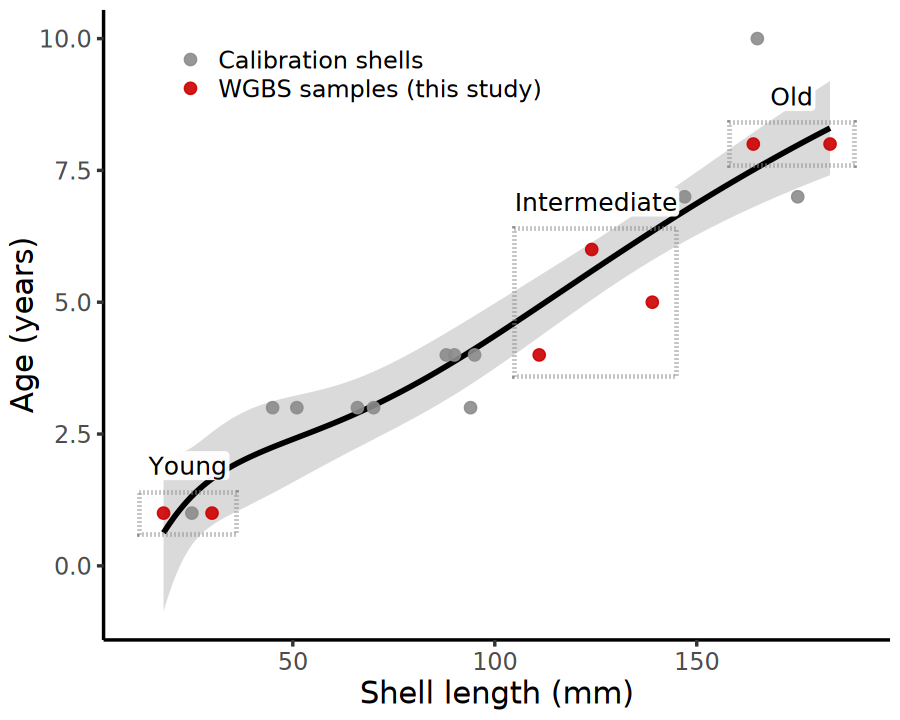

In [2]:
######################################################################
## BLOCK 1: GAM calibration + figure + WGBS age predictions
######################################################################

suppressMessages({
  library(mgcv); library(dplyr); library(ggplot2); library(scales); library(glue); library(tibble); library(Cairo)
})

## (A) Data ---------------------------------------------------------------------
calib <- tribble(
  ~id, ~length_mm, ~age_years,
   9,      18,        1,
  25,      25,        1,
  24,      30,        1,
  17,      45,        3,
  10,      51,        3,
  23,      66,        3,
   7,      70,        3,
  22,      88,        4,
  12,      90,        4,
  16,      94,        3,
   8,      95,        4,
  14,     111,        4,
  15,     124,        6,
  11,     139,        5,
  21,     147,        7,
  18,     164,        8,
  20,     165,       10,
  13,     175,        7,
  19,     183,        8
) %>%
  mutate(logL = log(length_mm))

## (B) Fit GAM (REML) -----------------------------------------------------------
m <- gam(age_years ~ s(logL, k = 4), data = calib, method = "REML")
s <- summary(m)

# Metrics
r2_adj <- s$r.sq                      # mgcv prints this as "R-sq.(adj)"
devexp <- s$dev.expl                  # "Deviance explained"
edf    <- as.numeric(s$s.table[1, "edf"])
Fstat  <- as.numeric(s$s.table[1, "F"])
pval   <- as.numeric(s$s.table[1, "p-value"])
rmse   <- sqrt(mean((calib$age_years - fitted(m))^2))

cat(glue("Adj. R^2 = {round(r2_adj,3)}, Dev. explained = {round(100*devexp,1)}%, ",
         "edf = {round(edf,2)}, F = {round(Fstat,2)}, p < {format.pval(pval, digits=2)}, ",
         "RMSE = {round(rmse,2)} years\n"))

######################################################################
## (C) WGBS IDs + age groups + predicted ages
######################################################################

# WGBS IDs + age groups (edit if your grouping differs)
wgbsi <- tibble(
  sample    = c("MC09","MC24","MC11","MC14","MC15","MC18","MC19"),
  id        = c(9, 24, 11, 14, 15, 18, 19),
  age_group = c("Young","Young","Intermediate","Intermediate","Intermediate","Old","Old")
)

# Attach WGBS labels to the calibration table
calib <- calib %>%
  mutate(id = as.integer(id)) %>%
  left_join(wgbsi %>% select(id, age_group), by = "id") %>%
  mutate(
    point_class = if_else(!is.na(age_group),
                          "WGBS samples (this study)",
                          "Calibration shells"),
    age_group = factor(age_group, levels = c("Young","Intermediate","Old"))
  )

# Predict ages for WGBS individuals (based on their shell length in calib)
pred_tbl <- calib %>%
  filter(point_class == "WGBS samples (this study)") %>%
  transmute(
    id, age_group, length_mm,
    pred_age = as.numeric(predict(m, newdata = tibble(logL = log(length_mm))))
  )

print(
  pred_tbl %>%
    left_join(wgbsi %>% select(id, sample), by = "id") %>%
    transmute(Sample = sample, `Length (mm)` = length_mm, `Predicted age (y)` = round(pred_age, 2), Group = age_group) %>%
    arrange(Sample),
  n = Inf
)

######################################################################
## (D) Prediction curve + CI (creates new_len)  << this was missing
######################################################################

new_len <- tibble(
  length_mm = seq(min(calib$length_mm), max(calib$length_mm), length.out = 300),
  logL      = log(length_mm)
)

pred <- as.data.frame(predict(m, newdata = new_len, se.fit = TRUE))
new_len$fit <- pred$fit
new_len$lo  <- pred$fit - 1.96 * pred$se.fit
new_len$hi  <- pred$fit + 1.96 * pred$se.fit

######################################################################
## (E) Group outline rectangles (dotted + light) + label positions
######################################################################

# Rectangle definitions computed from the WGBS points in each group
box_df <- calib %>%
  filter(point_class == "WGBS samples (this study)") %>%
  group_by(age_group) %>%
  summarise(
    xmin = min(length_mm) - 6,
    xmax = max(length_mm) + 6,
    ymin = min(age_years) - 0.4,
    ymax = max(age_years) + 0.4,
    .groups = "drop"
  ) %>%
  mutate(
    # place labels just above each box, centered
    xlab = (xmin + xmax) / 2,
    ylab = ymax + 0.25
  )

######################################################################
## (F) Figure (legend upper-left, no title, subtle dotted outlines)
######################################################################

LEG_POS <- c(0.03, 0.97)  # upper-left
LEG_JUS <- c(0, 1)

p_s1 <- ggplot() +
  geom_ribbon(data = new_len, aes(x = length_mm, ymin = lo, ymax = hi), alpha = 0.18) +
  geom_line(data = new_len, aes(x = length_mm, y = fit), linewidth = 1.2) +
  geom_point(
    data = calib,
    aes(x = length_mm, y = age_years, color = point_class),
    size = 2.8, alpha = 0.9
  ) +
  scale_color_manual(values = c(
    "Calibration shells" = "grey55",
    "WGBS samples (this study)" = "red3"
  )) +
  geom_rect(
    data = box_df,
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
    inherit.aes = FALSE,
    fill = NA,
    color = "grey55",
    linetype = "dotted",
    linewidth = 1
  ) +
geom_label(
  data = box_df %>% mutate(ylab = ylab + 0.25),
  aes(x = xlab, y = ylab, label = age_group),
  inherit.aes = FALSE,
  fontface = "plain",
  size = 5.2,
  label.size = 0,
  fill = "white",
  alpha = 0.95,
  label.padding = unit(0.08, "lines")
) +
  labs(
    x = "Shell length (mm)",
    y = "Age (years)",
    color = NULL
  ) +
  coord_cartesian(clip = "off") +
  theme_classic(base_size = 16) +
  theme(
    legend.position = c(0.05, 0.96),
    legend.justification = LEG_JUS,
    legend.text          = element_text(size = 14),
    axis.title           = element_text(size = 18),
    axis.text            = element_text(size = 14),
    legend.margin = margin(6, 6, 6, 20),
    plot.margin = margin(6, 6, 6, 6)
  )

# Print in notebook
old_opts <- options(repr.plot.width = 7.5, repr.plot.height = 6, repr.plot.res = 160)
print(p_s1)
options(old_opts)

# Save (match your convention)
ggsave(file.path(out_fig_dir, "Fig4.pdf"), p_s1,
       width = 7.5, height = 6, units = "in",
       device = grDevices::cairo_pdf, bg = "white")

In [3]:
######################################################################
## Reproducibility
######################################################################

cat("Date:", as.character(Sys.Date()), "\n")
cat("R version:", R.version.string, "\n\n")

pkgs <- c("mgcv","dplyr","ggplot2","scales","glue","tibble","Cairo")
cat("Key package versions:\n")
for (p in pkgs) {
  if (requireNamespace(p, quietly = TRUE)) {
    cat(sprintf("  %-10s %s\n", paste0(p, ":"), as.character(packageVersion(p))))
  } else {
    cat(sprintf("  %-10s %s\n", paste0(p, ":"), "not installed"))
  }
}


Date: 2026-07-30 
R version: R version 4.4.1 (2024-06-14) 

Key package versions:
  mgcv:      1.9.1
  dplyr:     1.1.4
  ggplot2:   3.5.2
  scales:    1.4.0
  glue:      1.8.0
  tibble:    3.2.1
  Cairo:     1.6.5
